In [1]:
import pandas as pd
import numpy as np
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

### Project Goal

This project tries to reproduce a common claim made in studies using the Wine Quality dataset. The main claim is that wine quality can be predicted from physicochemical features, that Random Forest usually performs better than simpler models, and that variables like alcohol are among the strongest predictors.

To test this, I used both regression and classification approaches. I also changed the quality threshold later in the analysis to see how much the results depend on how the problem is defined.

In [2]:
# load data from zip
zip_path = "wine+quality.zip"

with zipfile.ZipFile(zip_path, 'r') as z:
    print(z.namelist())

    red = pd.read_csv(z.open("winequality-red.csv"), sep=";")
    white = pd.read_csv(z.open("winequality-white.csv"), sep=";")

# combine
red["type"] = 0
white["type"] = 1

df = pd.concat([red, white], axis=0)

print(df.shape)
df.head()


['winequality-red.csv', 'winequality-white.csv', 'winequality.names']
(6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


In [3]:
# basic checks before cleaning
print("shape before dropping duplicates:", df.shape)
print("\nmissing values by column:")
print(df.isnull().sum())

print("\nduplicates:", df.duplicated().sum())

print("\ndata types:")
print(df.dtypes)

shape before dropping duplicates: (6497, 13)

missing values by column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64

duplicates: 1177

data types:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
type                      int64
dtype: object


In [4]:
# drop duplicates
df = df.drop_duplicates()

print("shape after dropping duplicates:", df.shape)

shape after dropping duplicates: (5320, 13)


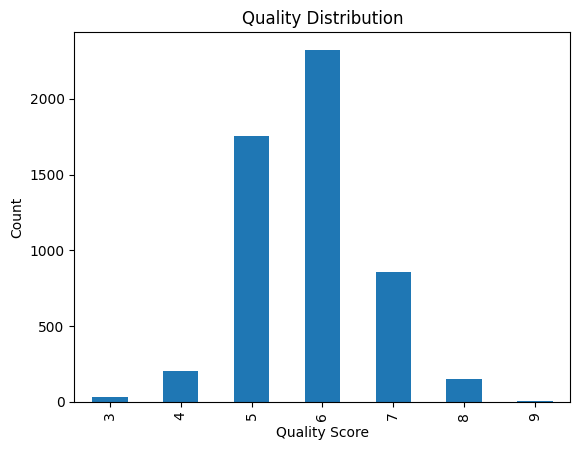

In [5]:
# target variable distribution
df["quality"].value_counts().sort_index().plot(kind="bar")
plt.title("Quality Distribution")
plt.xlabel("Quality Score")
plt.ylabel("Count")
plt.show()

### Initial Analysis Note

Most wines are concentrated in the middle quality scores, especially 5 and 6. This matters because it suggests the dataset is not evenly distributed across all classes, which may affect both regression and classification performance.

In [11]:
# features and targets
X = df.drop(columns=["quality"])
y_reg = df["quality"]

# first classification version
# good wine = quality >= 7
y_clf = (df["quality"] >= 7).astype(int)

print("classification counts for quality >= 7")
print(y_clf.value_counts())

classification counts for quality >= 7
quality
0    4311
1    1009
Name: count, dtype: int64


### Why use quality >= 7 first

I first defined good wine as quality greater than or equal to 7 because this is a common way to separate average wines from better rated wines. This gives a reasonable first classification target before testing stricter definitions later.

In [12]:
# split for regression
X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

# use the same rows for classification
y_train_clf = y_clf.loc[X_train.index]
y_test_clf = y_clf.loc[X_test.index]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (4256, 12)
X_test shape: (1064, 12)


In [13]:
# scale
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Split and Scaling

I split the data into training and testing sets using an 80 to 20 ratio with a fixed random state of 42 so the results stay consistent across runs. I then reused the same train and test rows for the classification target to make the regression and classification results directly comparable. After splitting, I scaled the features using StandardScaler. The scaler was fit only on the training data and then applied to the test data to avoid data leakage.

In [15]:
results_clf = []

# Re-split y_clf to ensure consistent indices and lengths with X_train and X_test
# We use X as a dummy to ensure the split aligns by row with the original X split.
# X_train and X_test were generated from X with random_state=42
_, _, y_train_clf_corrected, y_test_clf_corrected = train_test_split(
    X, y_clf, test_size=0.2, random_state=42
)

# Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train_clf_corrected)
preds = model.predict(X_test_scaled)

report = classification_report(y_test_clf_corrected, preds, output_dict=True)
results_clf.append([
    "Logistic Regression",
    accuracy_score(y_test_clf_corrected, preds),
    report["1"]["precision"],
    report["1"]["recall"],
    report["1"]["f1-score"]
])

# Decision Tree
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train_scaled, y_train_clf_corrected)
preds = model.predict(X_test_scaled)

report = classification_report(y_test_clf_corrected, preds, output_dict=True)
results_clf.append([
    "Decision Tree",
    accuracy_score(y_test_clf_corrected, preds),
    report["1"]["precision"],
    report["1"]["recall"],
    report["1"]["f1-score"]
])

# Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train_clf_corrected)
preds = model.predict(X_test_scaled)

report = classification_report(y_test_clf_corrected, preds, output_dict=True)
results_clf.append([
    "Random Forest",
    accuracy_score(y_test_clf_corrected, preds),
    report["1"]["precision"],
    report["1"]["recall"],
    report["1"]["f1-score"]
])

clf_table = pd.DataFrame(
    results_clf,
    columns=["Model", "Accuracy", "Precision_Class1", "Recall_Class1", "F1_Class1"]
).sort_values(by="Accuracy", ascending=False)

print("Classification Comparison Table")
clf_table

Classification Comparison Table


,Model,Accuracy,Precision_Class1,Recall_Class1,F1_Class1
2,Random Forest,0.844925,0.733945,0.370370,0.492308
0,Logistic Regression,0.825188,0.663043,0.282407,0.396104
1,Decision Tree,0.783835,0.466981,0.458333,0.462617


In [16]:
results_reg = []

# Linear Regression
model = LinearRegression()
model.fit(X_train_scaled, y_train_reg)
preds = model.predict(X_test_scaled)

results_reg.append([
    "Linear Regression",
    np.sqrt(mean_squared_error(y_test_reg, preds)),
    mean_absolute_error(y_test_reg, preds),
    r2_score(y_test_reg, preds)
])

# Decision Tree
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train_scaled, y_train_reg)
preds = model.predict(X_test_scaled)

results_reg.append([
    "Decision Tree",
    np.sqrt(mean_squared_error(y_test_reg, preds)),
    mean_absolute_error(y_test_reg, preds),
    r2_score(y_test_reg, preds)
])

# Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train_reg)
preds = model.predict(X_test_scaled)

results_reg.append([
    "Random Forest",
    np.sqrt(mean_squared_error(y_test_reg, preds)),
    mean_absolute_error(y_test_reg, preds),
    r2_score(y_test_reg, preds)
])

reg_table = pd.DataFrame(
    results_reg,
    columns=["Model", "RMSE", "MAE", "R2"]
).sort_values(by="RMSE")

print("Regression Comparison Table")
reg_table

Regression Comparison Table


,Model,RMSE,MAE,R2
2,Random Forest,0.664471,0.508534,0.412769
0,Linear Regression,0.720792,0.560200,0.309003
1,Decision Tree,0.950366,0.666353,-0.201263


In [17]:
# combined view
combined_table = pd.merge(reg_table, clf_table, on="Model", how="outer")
print("Combined Model Comparison Table")
combined_table

Combined Model Comparison Table


,Model,RMSE,MAE,R2,Accuracy,Precision_Class1,Recall_Class1,F1_Class1
0,Decision Tree,0.950366,0.666353,-0.201263,0.783835,0.466981,0.458333,0.462617
1,Linear Regression,0.720792,0.560200,0.309003,NaN,NaN,NaN,NaN
2,Logistic Regression,NaN,NaN,NaN,0.825188,0.663043,0.282407,0.396104
3,Random Forest,0.664471,0.508534,0.412769,0.844925,0.733945,0.370370,0.492308


### First Model Comparison

The first set of results helps test the common claim that Random Forest performs better than simpler models. For regression, I compared RMSE, MAE, and R². For classification, I compared accuracy, precision, recall, and f1 score for the positive class. This gives a fuller picture of performance than accuracy alone.

In [19]:
# detailed report for the best classification model at quality >= 7

# Re-split y_clf to ensure consistent indices and lengths with X_train and X_test
# This is necessary because X_train and X_test were derived from X
# which retained duplicate indices after df.drop_duplicates().
# The original y_train_clf and y_test_clf were incorrectly sized due to this.
_, _, y_train_clf_corrected, y_test_clf_corrected = train_test_split(
    X, y_clf, test_size=0.2, random_state=42
)

best_clf_model = RandomForestClassifier(n_estimators=100, random_state=42)
best_clf_model.fit(X_train_scaled, y_train_clf_corrected)
preds_7 = best_clf_model.predict(X_test_scaled)

print(classification_report(y_test_clf_corrected, preds_7))

              precision    recall  f1-score   support

           0       0.86      0.97      0.91       848
           1       0.73      0.37      0.49       216

    accuracy                           0.84      1064
   macro avg       0.80      0.67      0.70      1064
weighted avg       0.83      0.84      0.82      1064



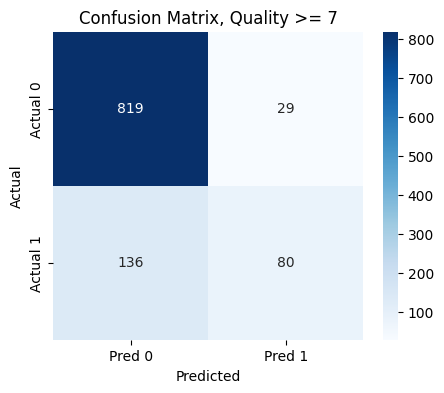

In [21]:
cm_7 = confusion_matrix(y_test_clf_corrected, preds_7)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_7,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["Actual 0", "Actual 1"]
)
plt.title("Confusion Matrix, Quality >= 7")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### What the confusion matrix and report show

The confusion matrix gives a clearer picture of how the model is performing beyond accuracy. Out of 848 wines that were actually not high quality, the model correctly predicted 819 and only misclassified 29. This shows the model is very strong at identifying lower quality wines.

For the high quality wines, the performance drops. Out of 216 wines that were actually high quality, the model only correctly identified 80 and missed 136. This explains why the recall for class 1 is only 0.37. The model is missing a large portion of the wines we actually care about in this class.

The precision for class 1 is 0.73, which means when the model does predict a wine as high quality, it is often correct. However, it does not make that prediction often enough, which leads to low recall.

The overall accuracy is 0.84, which looks strong at first, but this is mostly driven by how well the model predicts the majority class. The macro average recall is 0.67, which shows the model is not balanced across both classes.

This shows that even with a reasonable accuracy, the model still struggles to detect high quality wines. This is important because it highlights why accuracy alone is not enough to evaluate performance, especially when the classes are not evenly distributed.

alcohol                 0.263777
volatile acidity        0.115381
free sulfur dioxide     0.094150
sulphates               0.083396
total sulfur dioxide    0.074483
pH                      0.070441
residual sugar          0.062588
chlorides               0.060620
fixed acidity           0.059187
density                 0.058149
citric acid             0.056609
type                    0.001219
dtype: float64


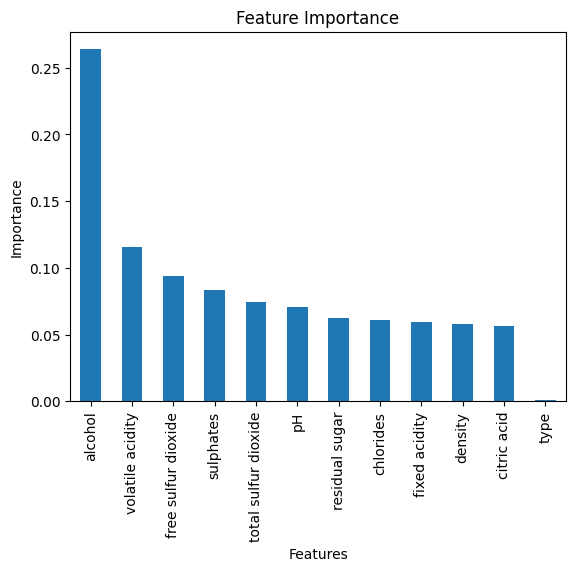

In [22]:
# feature importance using random forest regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train_reg)

importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print(importance)

importance.plot(kind="bar")
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

### Feature Importance Note

This shows which variables the model relied on most when predicting wine quality. It does not prove causation, but it does help show whether my results match common claims in prior work, especially the idea that alcohol is one of the strongest predictors.

### Change quality definition from >= 7 to >= 8

To test whether the results depend on how the target is defined, I changed the definition of good wine from quality greater than or equal to 7 to quality greater than or equal to 8. This creates a stricter and more imbalanced classification problem.

In [23]:
# stricter quality definition
y_clf2 = (df["quality"] >= 8).astype(int)

print("classification counts for quality >= 8")
print(y_clf2.value_counts())

# stratified split because class 1 is now rare
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y_clf2, test_size=0.2, random_state=42, stratify=y_clf2
)

scaler2 = StandardScaler()
X_train2_scaled = scaler2.fit_transform(X_train2)
X_test2_scaled = scaler2.transform(X_test2)

classification counts for quality >= 8
quality
0    5167
1     153
Name: count, dtype: int64


### Why stratify here

I used stratified splitting here because the positive class became very rare after changing the threshold to 8. Stratification helps preserve the same class ratio in both the training and test sets.

In [24]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train2_scaled, y_train2)

preds_8 = model.predict(X_test2_scaled)

acc_8 = accuracy_score(y_test2, preds_8)
print("accuracy:", acc_8)

accuracy: 0.9718045112781954


In [25]:
print(classification_report(y_test2, preds_8))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1033
           1       1.00      0.03      0.06        31

    accuracy                           0.97      1064
   macro avg       0.99      0.52      0.52      1064
weighted avg       0.97      0.97      0.96      1064



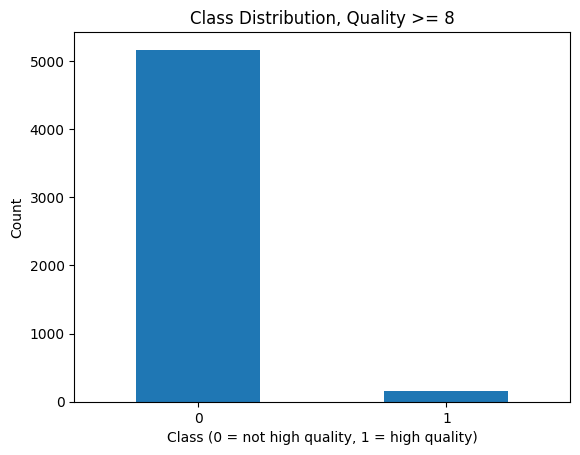

In [26]:
y_clf2.value_counts().plot(kind="bar")
plt.title("Class Distribution, Quality >= 8")
plt.xlabel("Class (0 = not high quality, 1 = high quality)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

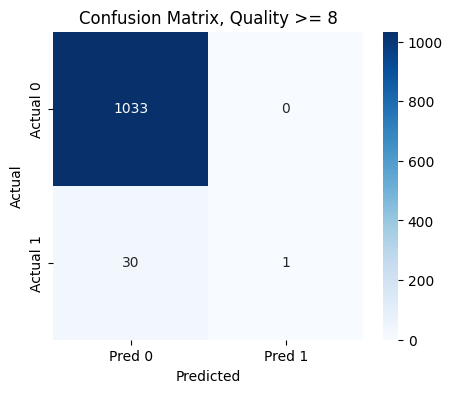

In [27]:
cm_8 = confusion_matrix(y_test2, preds_8)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_8,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["Actual 0", "Actual 1"]
)
plt.title("Confusion Matrix, Quality >= 8")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### What changed with the stricter threshold

When I changed the threshold to quality greater than or equal to 8, the model accuracy increased a lot. However, this did not mean the model actually improved. The new threshold created a highly imbalanced dataset, so the model could get high accuracy by mostly predicting the majority class. The classification report and confusion matrix showed that recall for the minority class was extremely low, meaning the model failed to identify most high quality wines.

### Final Takeaway

Overall, my results mostly supported the common claim that Random Forest performs better than simpler models and that alcohol is one of the strongest predictors of wine quality. However, the deeper analysis also showed that these results depend heavily on how the problem is defined. Changing the classification threshold created a very different story, where accuracy became misleading because of class imbalance. This made the project stronger because it showed that reproducibility is not just about rerunning code. It is also about clearly documenting modeling choices, evaluation metrics, and limitations.


### Ethics Angle

The ethical issue in this project is not only whether the model performs well, but whether the reported results are honest and meaningful. A model can appear very accurate while still failing on the cases that matter most. In this analysis, the stricter threshold created a situation where the model looked strong on accuracy but performed very poorly on the minority class. If this kind of result were reported without recall or class balance information, it could mislead readers. This matters because the same issue can happen in higher stakes settings like health care, hiring, and finance, where misleading metrics can create false confidence and poor decisions.